In [7]:
import pickle
from main import Result
from src import SBsim
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
open_file = open("/home/gkittles/SB_DRIPP_Results/1_31_25_No_Change/test_results87_0.83_1.dat", "rb")
obj = pickle.load(open_file)

In [ ]:
open_file2 = open("/home/gkittles/DRIPP/results/test_results87_0.83_1.dat", "rb")
obj2 = pickle.load(open_file2)

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_trees(ptrees):
    fig, axes = plt.subplots(1, len(ptrees), figsize=(30, 6))
    if len(ptrees) == 1:
        axes = [axes]
    
    for ax, ptree in zip(axes, ptrees):
        G = nx.DiGraph()
        pos = {}
        labels = {}
        edge_labels = {}
        
        def add_nodes_edges(node, parent=None, pos_x=0, pos_y=0, depth=1, is_left=None):
            node_id = id(node)
            pos[node_id] = (pos_x, -pos_y)
            labels[node_id] = str(node)
            G.add_node(node_id)
            
            if parent is not None:
                G.add_edge(id(parent), node_id)
                edge_labels[(id(parent), node_id)] = "True" if is_left else "False"
            
            if hasattr(node, 'l') and node.l:
                add_nodes_edges(node.l, node, pos_x - 1 / depth, pos_y + 1, depth + 1, is_left=True)
            if hasattr(node, 'r') and node.r:
                add_nodes_edges(node.r, node, pos_x + 1 / depth, pos_y + 1, depth + 1, is_left=False)
        
        add_nodes_edges(ptree.root, is_left=None)
        axes[0].set_title('Deploy Centralized')
        axes[1].set_title('Deploy Decentralized')
        axes[2].set_title('Curtailment')
        axes[3].set_title('Decommision Centralized')
        axes[4].set_title('Decommision Decentralized')
        
        nx.draw(G, pos, with_labels=True, labels=labels, node_size=2000, node_color='lightblue', font_size=6, edge_color='gray', ax=ax)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, ax=ax)
    
    plt.show()


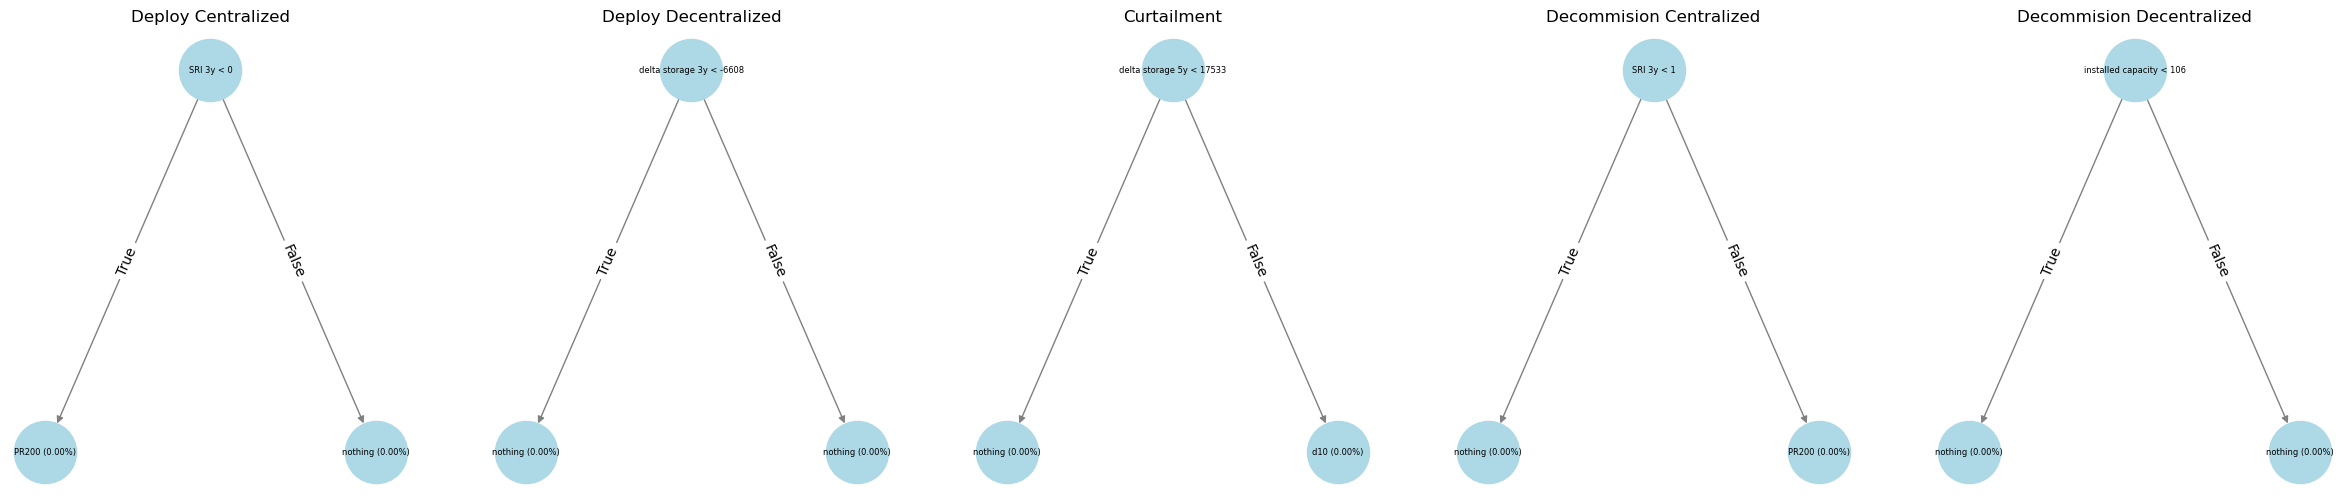

In [15]:
plot_trees(obj.best_solution)

In [16]:
plot_trees(obj2.initial_solution)

NameError: name 'obj2' is not defined

In [ ]:
from ptreeopt.tree import PTree
L1 = [[2,0],['PR200'],['nothing']]
L2 = [[8,11956],['nothing'],['PR50']]
L3 = [[0,3000],['d10'],['nothing']]
L4 = [[2,1],['nothing'],['PR200']]
L5 = [[8,-4481],['PR50'],['nothing']]
feature_names=['Surface Storage','SRI 1y', 'SRI 3y','allocation 1y','allocation 3y','allocation 5y','delta storage 1y','delta storage 3y',
               'delta storage 5y','installed capacity', 'capacity under construction', 'curtailment']
discrete_features = None
tree1 = PTree(L1,feature_names,discrete_features)
tree2 = PTree(L2,feature_names,discrete_features)
tree3 = PTree(L3,feature_names,discrete_features)
tree4 = PTree(L4,feature_names,discrete_features)
tree5 = PTree(L5,feature_names,discrete_features)

plot_trees([tree1,tree2,tree3,tree4,tree5])


In [ ]:
print(tree1.root.l.value)

In [27]:
# set optimization parameters
class OptimizationParameters(object):
    def __init__(self):
        self.cores    = 36 # this value is used only in the full scale optimization
        self.nseeds   = 1
        self.nobjs    = 1
        self.drought_type = [87, 0.83, 2] # set drought type here [Persistence (months), Intensity (unitless), Frequency (droughts/100 years)]

#initialize action table
action = [] #Action Name
capacity = [] #Capacity (Acre-Feet/Month)
om = [] #Operation and Maintenance Costs (Million Dollars/ Acre-Feet/ Year)
cx = [] #CAPEX (Million Dollars)
lifetime = [] #Years
t_depl = [] #Time to Deployment (Month)
action_type = [] # types 1: Deploy Centralized Infrastructure, 2: Commision Decentralized Infrastructure, 3: Decommission Centralized Infrastructure, 4: Decommission Centralized Infrastructure, 5: Conservation

#Read the action table
df_actions_table = pd.read_csv("data/actions_table.csv")
action = df_actions_table['action'].values
capacity = df_actions_table['capacity (af/month)'].values
om = df_actions_table['OPEX ($10^6/af/year)'].values
cx = df_actions_table['CAPEX($10^6)'].values
t_depl = df_actions_table['time to deployment (month)'].values
lifetime = df_actions_table['lifetime (year)'].values
action_type = [int(val) for val in df_actions_table['action_type'].values]

action_name = [[], [], [], [], []]
i = 0
for act in action:
        action_name[action_type[i]].extend( [act] )
        i += 1

opt_par = OptimizationParameters()
model_sim = SBsim(opt_par, action_name, capacity, om, cx, t_depl, lifetime) 
log = model_sim.simulate(obj.best_solution, 49)

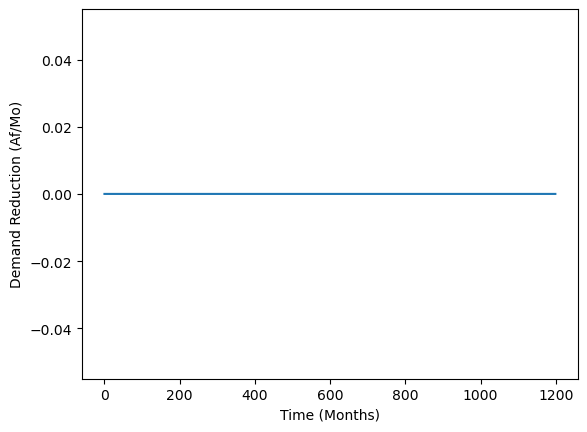

In [18]:
plt.plot(log.reduction_magn);
plt.xlabel('Time (Months)');
plt.ylabel('Demand Reduction (Af/Mo)');
#plt.xlim(590,650);

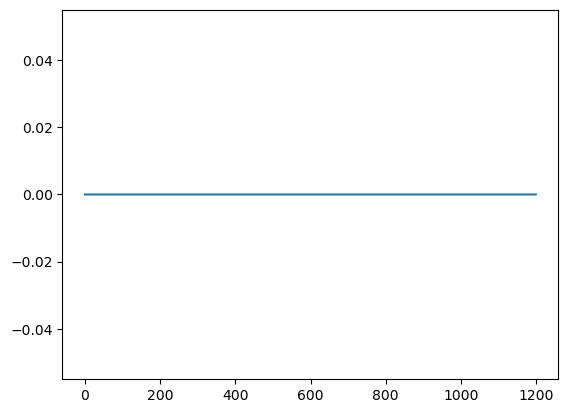

In [19]:
plt.plot(log.reduction_perc);

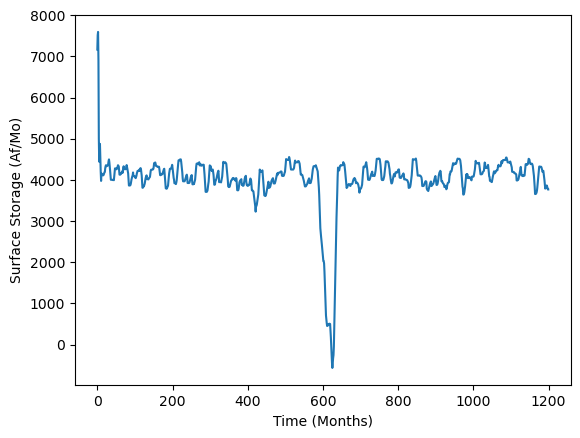

In [20]:
plt.plot(log.ss);
plt.xlabel('Time (Months)');
plt.ylabel('Surface Storage (Af/Mo)');

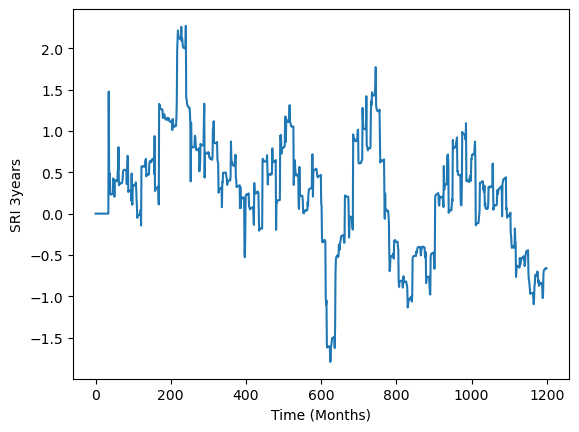

In [21]:
plt.plot(log.sri36);
plt.xlabel('Time (Months)');
plt.ylabel('SRI 3years');

In [28]:
print(log.Cost)

1.7321840450116435


In [12]:
print(log.rules_con)
print(log.thresh_con)
#print(log.indicators)
#print(len(log.indicators))

[['SRI 3y']]
[[np.float64(-1.314597839469017)]]


In [4]:
#Plotting the cost of curtailment experiment
open_file1 = open("/home/gkittles/SB_DRIPP_Results/2_20_25_Demand_Sensitivity/test_results87_0.83_10.dat", "rb")
obj1 = pickle.load(open_file1)
open_file2 = open("/home/gkittles/SB_DRIPP_Results/2_20_25_Demand_Sensitivity/test_results87_0.83_11000.dat", "rb")
obj2 = pickle.load(open_file2)
open_file3 = open("/home/gkittles/SB_DRIPP_Results/2_20_25_Demand_Sensitivity/test_results87_0.83_12000.dat", "rb")
obj3 = pickle.load(open_file3)
open_file4 = open("/home/gkittles/SB_DRIPP_Results/2_20_25_Demand_Sensitivity/test_results87_0.83_13000.dat", "rb")
obj4 = pickle.load(open_file4)
open_file5 = open("/home/gkittles/SB_DRIPP_Results/2_20_25_Demand_Sensitivity/test_results87_0.83_14000.dat", "rb")
obj5 = pickle.load(open_file5)
open_file6 = open("/home/gkittles/SB_DRIPP_Results/2_20_25_Demand_Sensitivity/test_results87_0.83_15000.dat", "rb")
obj6 = pickle.load(open_file6)
open_file7 = open("/home/gkittles/SB_DRIPP_Results/1_31_25_No_Change/test_results87_0.83_1.dat", "rb")
obj7 = pickle.load(open_file7)

In [5]:
logging = []
for obj in [obj1,obj2,obj3,obj4,obj5,obj6,obj7]:
    # set optimization parameters
    class OptimizationParameters(object):
        def __init__(self):
            self.cores    = 36 # this value is used only in the full scale optimization
            self.nseeds   = 1
            self.nobjs    = 1
            self.drought_type = [87, 0.83, 2] # set drought type here [Persistence (months), Intensity (unitless), Frequency (droughts/100 years)]

    #initialize action table
    action = [] #Action Name
    capacity = [] #Capacity (Acre-Feet/Month)
    om = [] #Operation and Maintenance Costs (Million Dollars/ Acre-Feet/ Year)
    cx = [] #CAPEX (Million Dollars)
    lifetime = [] #Years
    t_depl = [] #Time to Deployment (Month)
    action_type = [] # types 1: Deploy Centralized Infrastructure, 2: Commision Decentralized Infrastructure, 3: Decommission Centralized Infrastructure, 4: Decommission Centralized Infrastructure, 5: Conservation

    #Read the action table
    df_actions_table = pd.read_csv("data/actions_table.csv")
    action = df_actions_table['action'].values
    capacity = df_actions_table['capacity (af/month)'].values
    om = df_actions_table['OPEX ($10^6/af/year)'].values
    cx = df_actions_table['CAPEX($10^6)'].values
    t_depl = df_actions_table['time to deployment (month)'].values
    lifetime = df_actions_table['lifetime (year)'].values
    action_type = [int(val) for val in df_actions_table['action_type'].values]

    action_name = [[], [], [], [], []]
    i = 0
    for act in action:
            action_name[action_type[i]].extend( [act] )
            i += 1

    opt_par = OptimizationParameters()
    model_sim = SBsim(opt_par, action_name, capacity, om, cx, t_depl, lifetime) 
    logging.append(model_sim.simulate(obj.best_solution, 49))

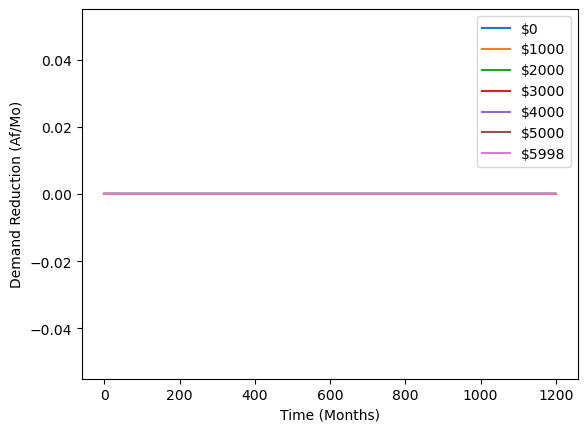

In [22]:

plt.plot(logging[0].reduction_magn, label = "$0");
plt.plot(logging[1].reduction_magn, label = "$1000");
plt.plot(logging[2].reduction_magn, label = "$2000");
plt.plot(logging[3].reduction_magn, label = "$3000");
plt.plot(logging[4].reduction_magn, label = "$4000");
plt.plot(logging[5].reduction_magn, label = "$5000");
plt.plot(logging[6].reduction_magn, label = "$5998")
plt.xlabel('Time (Months)');
plt.ylabel('Demand Reduction (Af/Mo)');
plt.legend();

In [9]:
for log in logging:
    print(log.rules_con)
    print(log.thresh_con)

[['capacity under construction']]
[[331.1180112123686]]
[['delta storage 5y']]
[[np.float64(-10525.132868396437)]]
[['delta storage 1y']]
[[np.float64(-16115.020217889843)]]
[['SRI 1y']]
[[np.float64(-1.3392805818965638)]]
[['Surface Storage']]
[[np.float64(23853.845624193855)]]
[['installed capacity']]
[[np.float64(738.2464028096704)]]
[['delta storage 5y']]
[[np.float64(17533.560757201463)]]


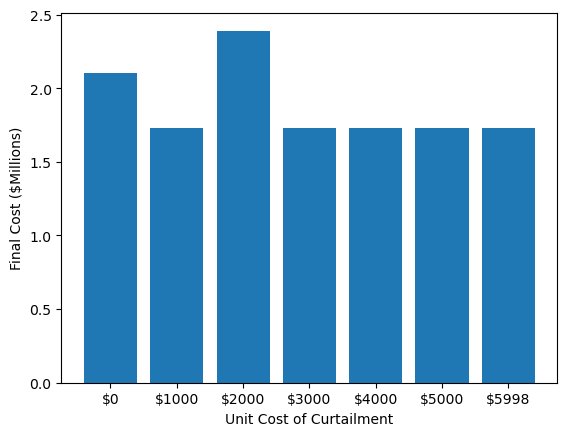

In [11]:
plt.bar(["$0","$1000","$2000","$3000","$4000","$5000","$5998"],[logging[0].Cost,logging[1].Cost,logging[2].Cost,logging[3].Cost,logging[4].Cost,logging[5].Cost,logging[6].Cost])
plt.xlabel("Unit Cost of Curtailment");
plt.ylabel("Final Cost ($Millions)");

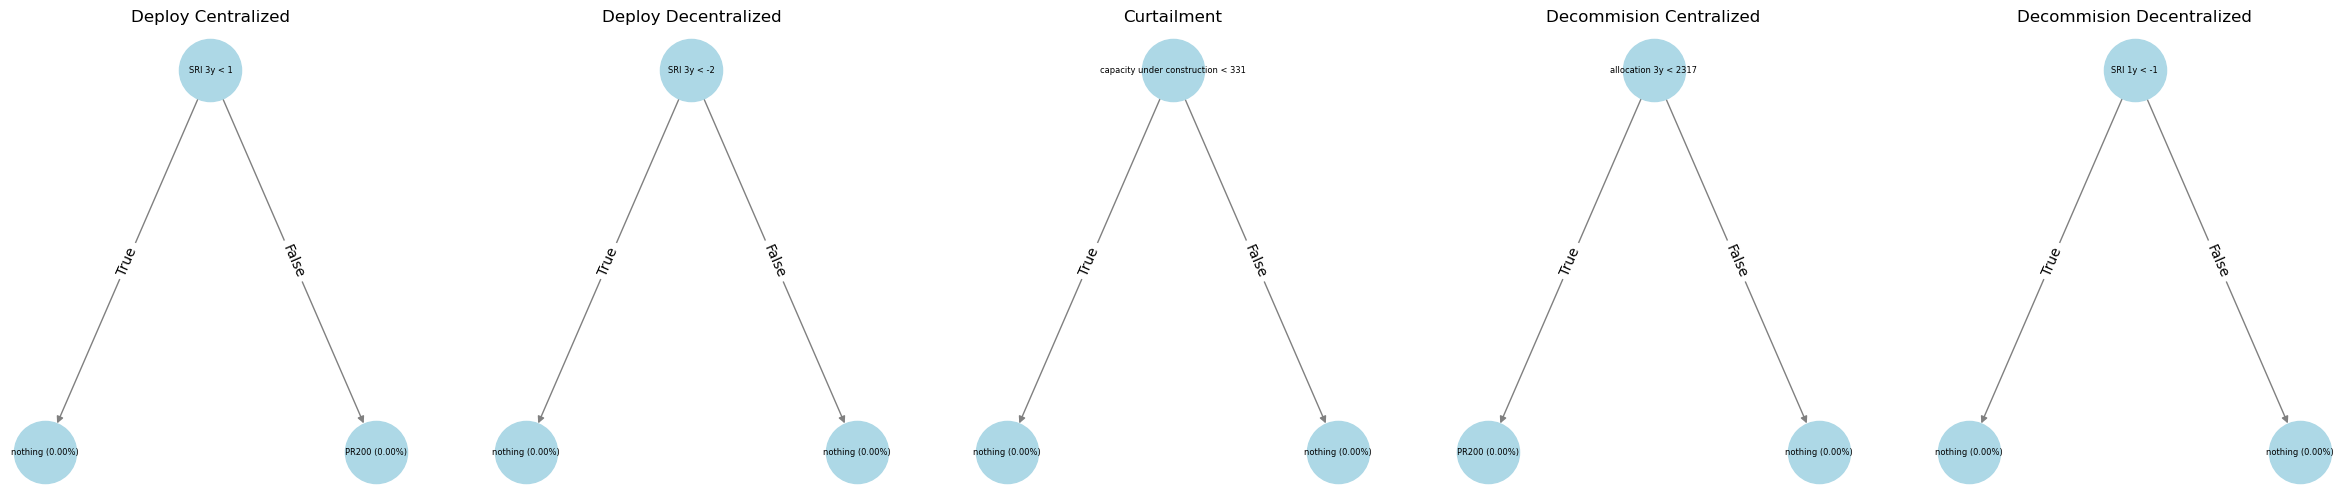

In [15]:
plot_trees(obj1.best_solution)

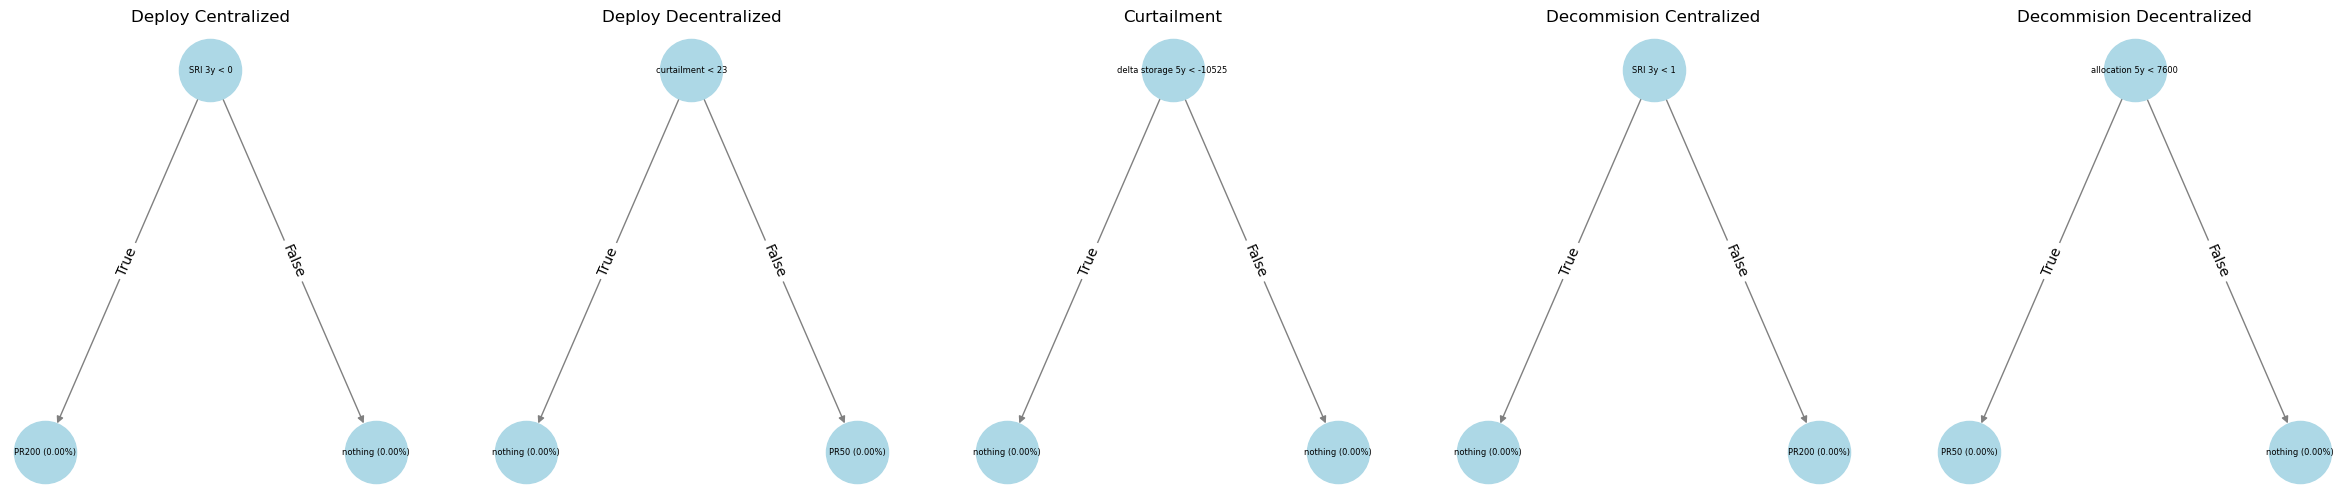

In [16]:
plot_trees(obj2.best_solution)

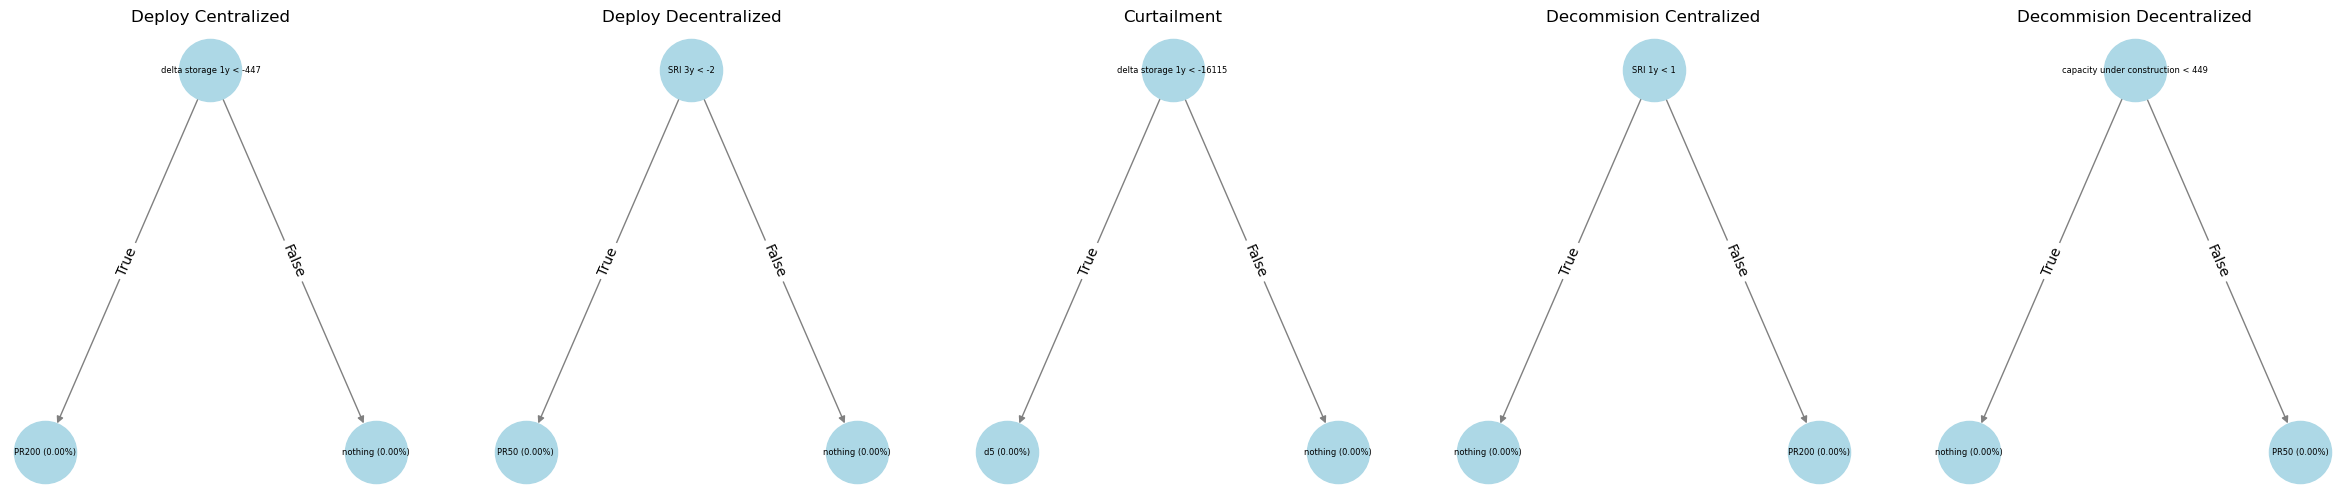

In [17]:
plot_trees(obj3.best_solution)

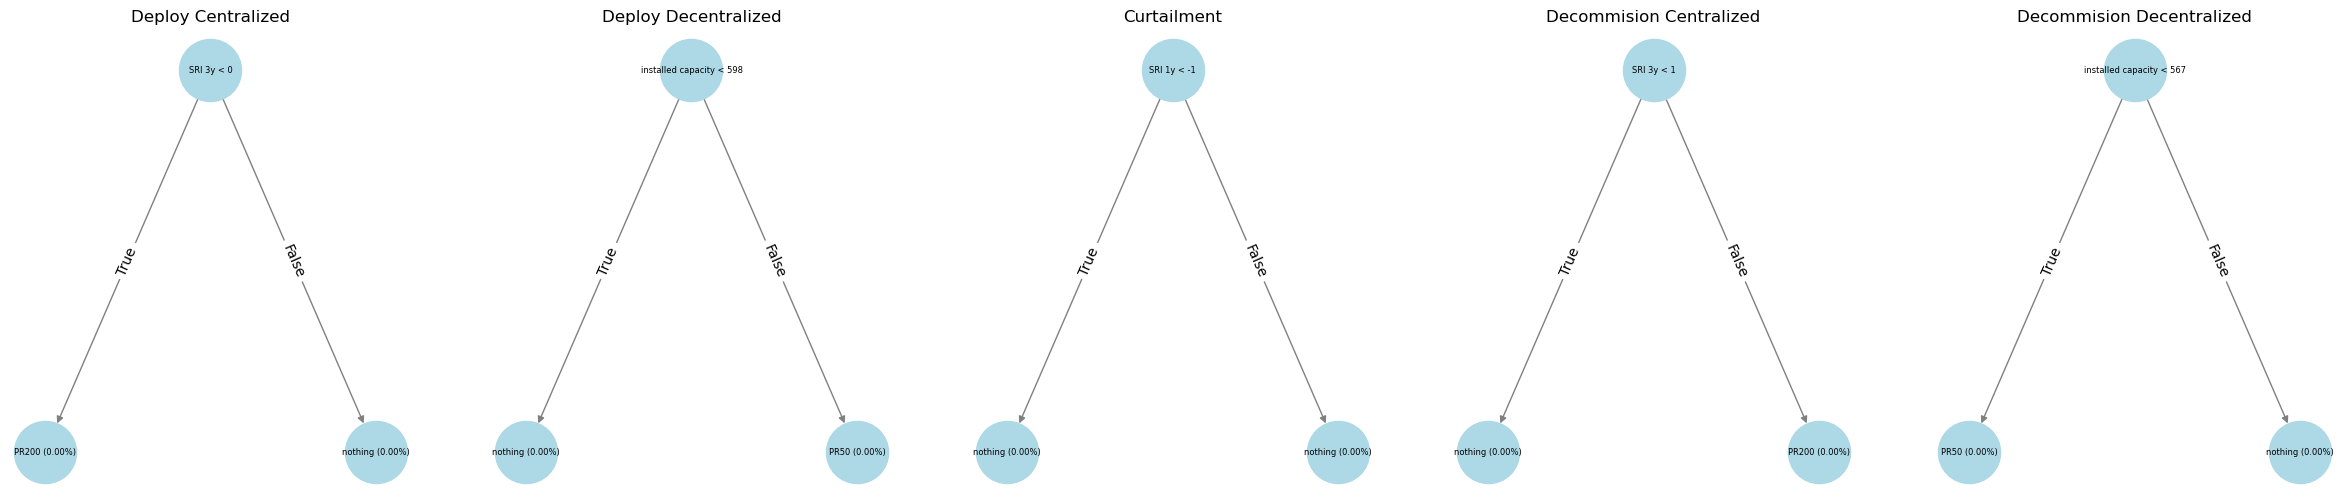

In [18]:
plot_trees(obj4.best_solution)

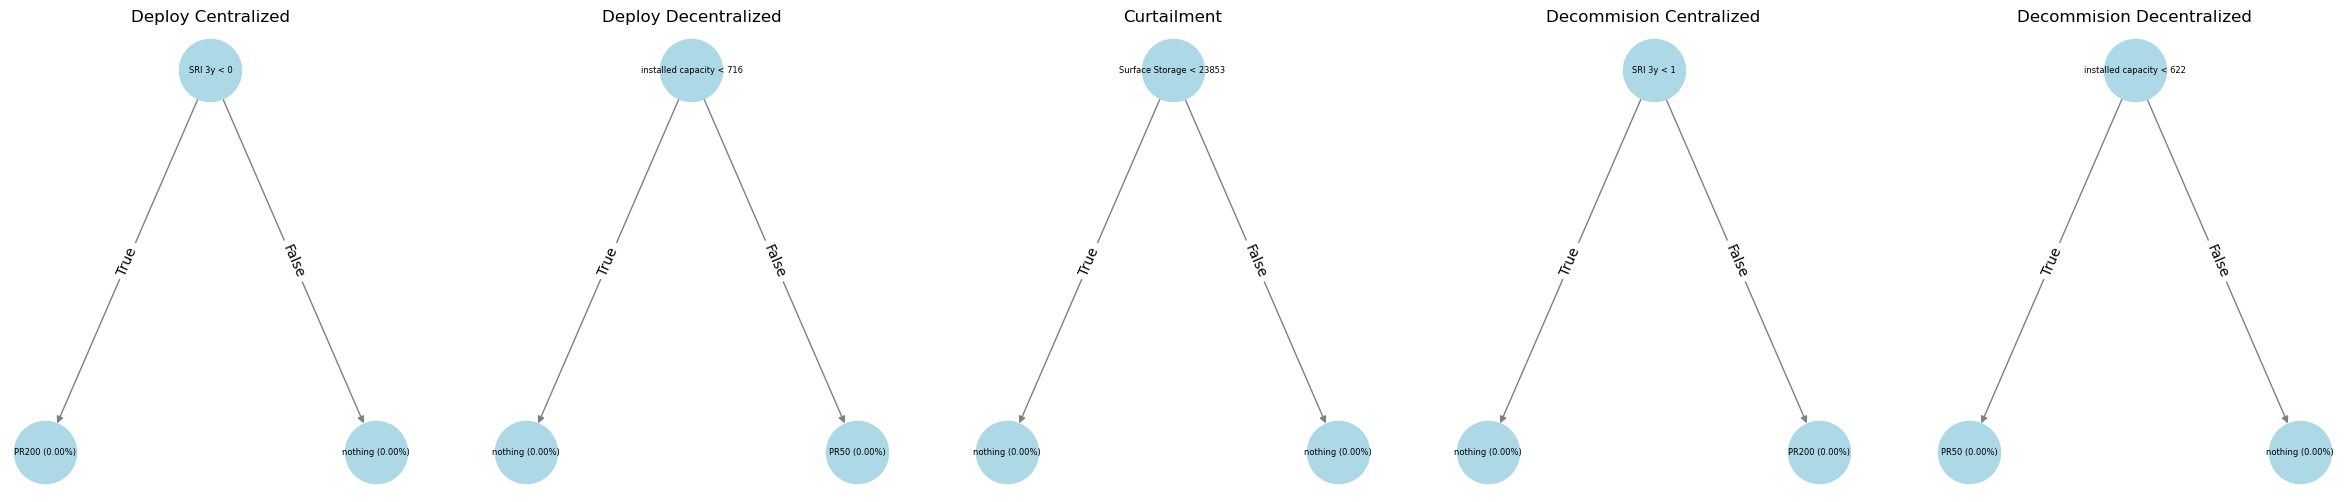

In [19]:
plot_trees(obj5.best_solution)

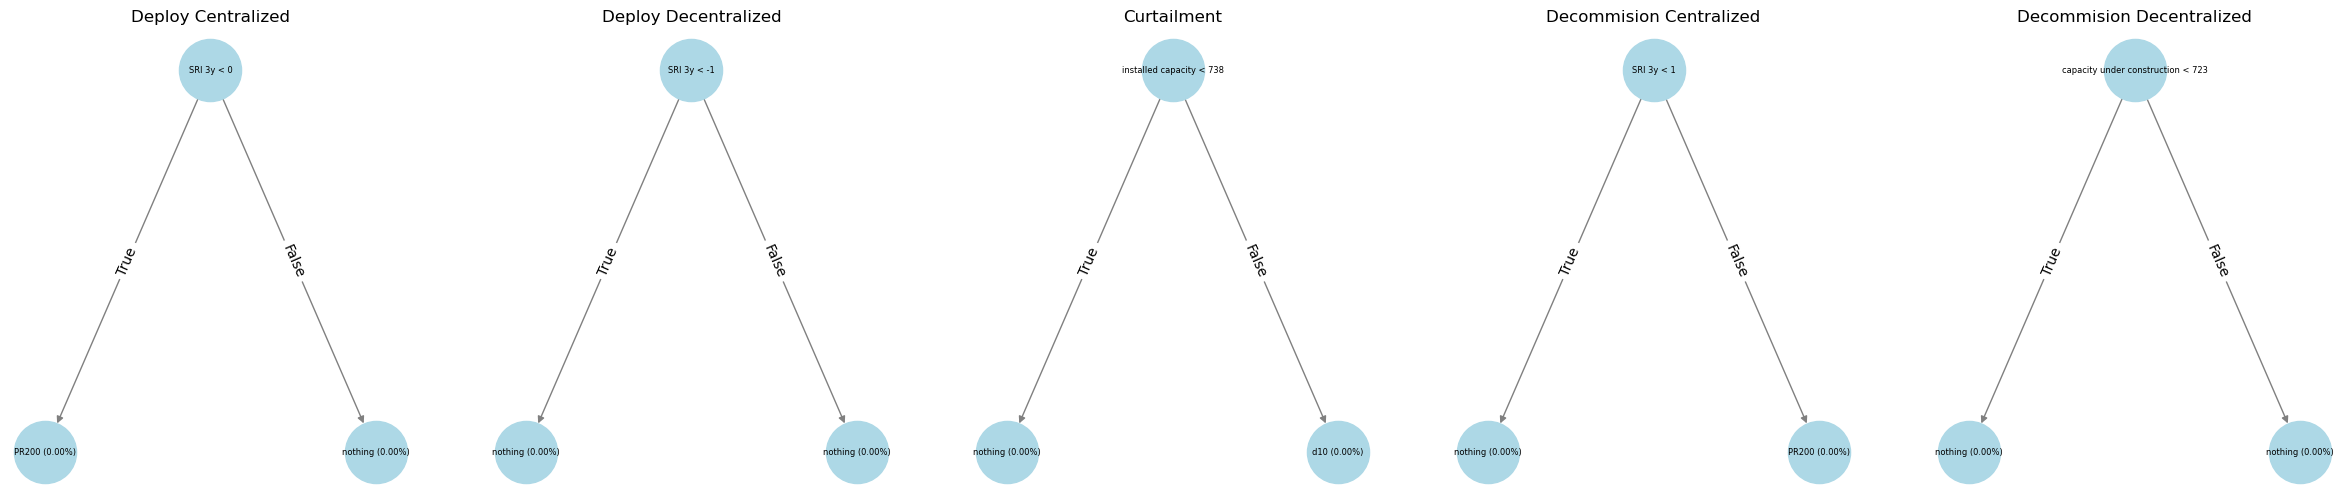

In [20]:
plot_trees(obj6.best_solution)

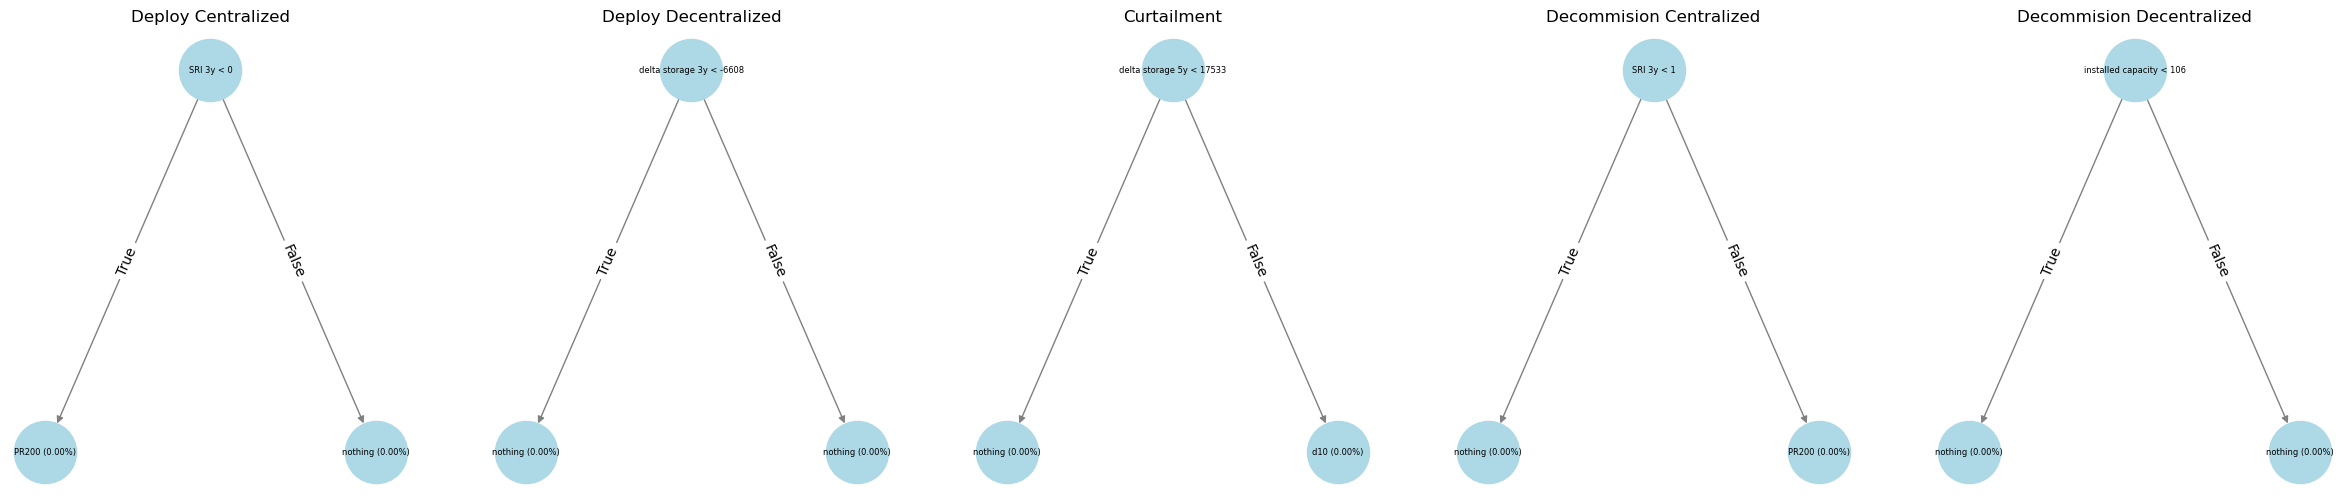

In [21]:
plot_trees(obj7.best_solution)